<a href="https://colab.research.google.com/github/lexinejazly-asuncion/Hallucination_Detection/blob/main/Hallucination_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI Ignite Summer 2026: Hallucination Detection Machine Learning Project**
Team Members: Lexinejazly Asuncion, Santhosh Senthil, Siddarth Shekhar

# Imports


In [38]:
# ── IMPORTS ─────────────────────────────────────────────────
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted")


# Loading Dataset


In [39]:
# ── LOAD ────────────────────────────────────────────────────
dev  = pd.read_parquet("hf://datasets/lytang/LLM-AggreFact/data/dev-00000-of-00001.parquet")
test = pd.read_parquet("hf://datasets/lytang/LLM-AggreFact/data/test-00000-of-00001.parquet")

print(f"dev:  {dev.shape}")
print(f"test: {test.shape}")
print(f"columns: {dev.columns.tolist()}")

dev:  (30420, 5)
test: (29320, 5)
columns: ['dataset', 'doc', 'claim', 'label', 'contamination_identifier']


# Data Split

In [40]:
# ── SPLIT FIRST (before touching anything) ──────────────────
# stratify on BOTH label and source dataset so each split
# keeps the same class balance and the same source mix
dev["strat_key"] = dev["label"].astype(str) + "_" + dev["dataset"].astype(str)

train_df, val_df = train_test_split(
    dev,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=dev["strat_key"]
)

train_df = train_df.drop(columns=["strat_key"]).reset_index(drop=True)
val_df   = val_df.drop(columns=["strat_key"]).reset_index(drop=True)
test_df  = test.reset_index(drop=True)   # sealed, do not look at

print(f"\ntrain: {len(train_df):,}")
print(f"val:   {len(val_df):,}")
print(f"test:  {len(test_df):,}  (held out)")


train: 24,336
val:   6,084
test:  29,320  (held out)


# Sanity & Summary


Label balance per split:
  train: 75.7% supported (label=1)
  val: 75.7% supported (label=1)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24336 entries, 0 to 24335
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   dataset                   24336 non-null  object
 1   doc                       24336 non-null  object
 2   claim                     24336 non-null  object
 3   label                     24336 non-null  int64 
 4   contamination_identifier  24336 non-null  object
dtypes: int64(1), object(4)
memory usage: 950.8+ KB
None

Nulls:
 dataset                     0
doc                         0
claim                       0
label                       0
contamination_identifier    0
dtype: int64

Duplicate rows: 38

Class distribution:
label
0     5921
1    18415
Name: count, dtype: int64
Imbalance ratio: 3.11x


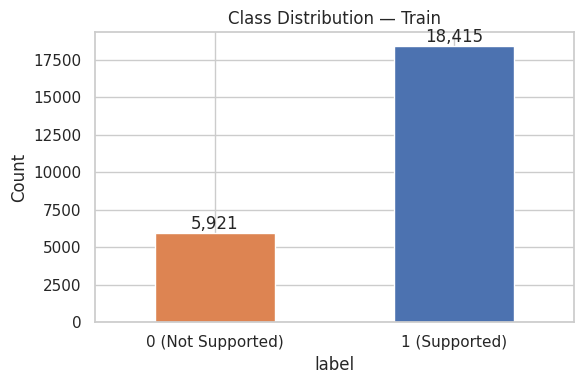


        doc_len  claim_len
count  24336.0    24336.0
mean     469.1       19.7
std      737.3        9.7
min        2.0        1.0
25%      180.0       13.0
50%      322.0       18.0
75%      560.0       24.0
max    25872.0      221.0


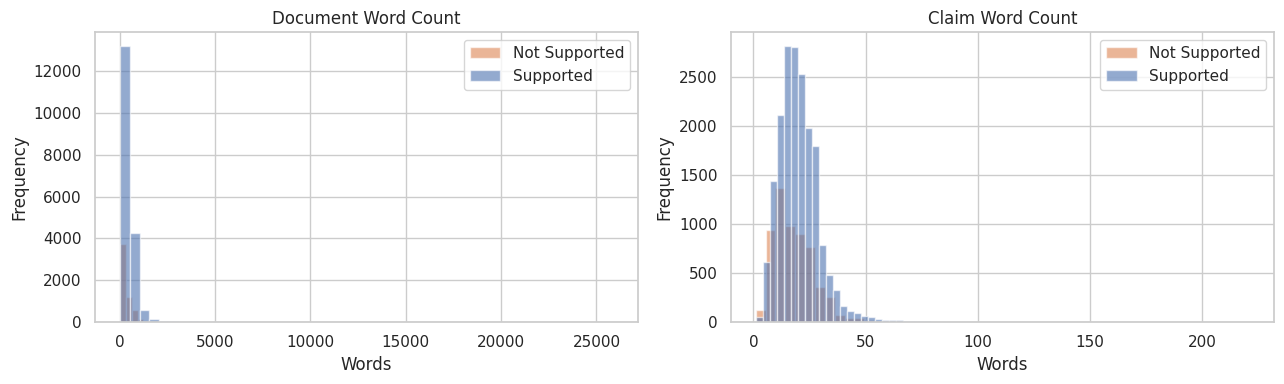


Mean length by label:
       doc_len  claim_len
label                    
0        378.1       18.2
1        498.4       20.2

Samples per source:
dataset
RAGTruth           12272
ExpertQA            3019
Lfqa                1623
TofuEval-MediaS     1440
Reveal              1325
TofuEval-MeetB      1285
FactCheck-GPT       1230
ClaimVerify          875
AggreFact-XSum       621
AggreFact-CNN        367
Wice                 279
Name: count, dtype: int64

Supported rate (%) per source:
dataset
FactCheck-GPT      17.3
Reveal             23.2
Wice               33.0
AggreFact-XSum     50.7
Lfqa               56.7
ClaimVerify        75.1
ExpertQA           77.9
TofuEval-MediaS    80.3
TofuEval-MeetB     82.0
AggreFact-CNN      87.2
RAGTruth           89.8
Name: label, dtype: float64


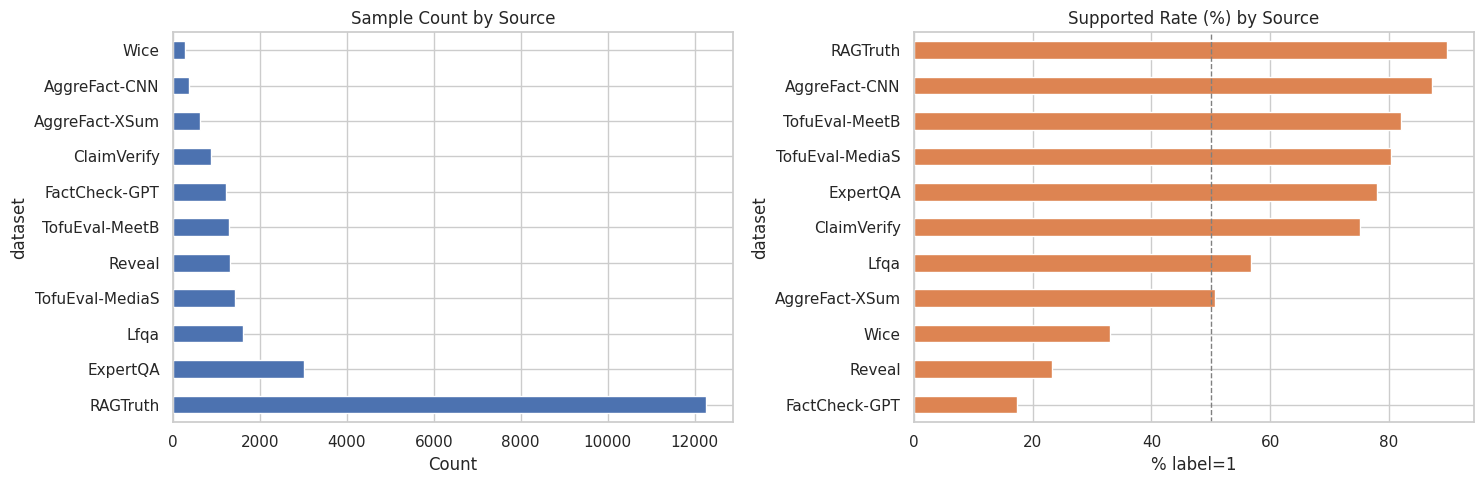


Top 5% longest docs: 1,217 rows
  range: 1,065 to 25,872 words
  median doc overall: 322 words
  source breakdown of outliers:
dataset
ClaimVerify       420
RAGTruth          407
ExpertQA          238
Wice              129
AggreFact-CNN      12
AggreFact-XSum     11
Name: count, dtype: int64
TRAIN SET SUMMARY
Rows:                24,336
Supported (1):       18,415
Not supported (0):   5,921
Imbalance ratio:     3.11x
Sources:             11
Median doc length:   322 words
Median claim length: 18 words
Longest doc:         25,872 words
Most imbalanced src: FactCheck-GPT (17.3% supported)


In [41]:
# ── SANITY CHECK: did stratification hold? ──────────────────
print("\nLabel balance per split:")
for name, df in [("train", train_df), ("val", val_df)]:
    pct = df["label"].mean() * 100
    print(f"  {name}: {pct:.1f}% supported (label=1)")


# ══════════════════════════════════════════════════════════════
#  SUMMARY STATS  —  TRAIN SET ONLY FROM HERE DOWN
# ══════════════════════════════════════════════════════════════

df = train_df.copy()


# ── 1. STRUCTURE ────────────────────────────────────────────
print(df.info())
print("\nNulls:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated(subset=["doc", "claim"]).sum())



# ── 2. CLASS BALANCE ────────────────────────────────────────
label_counts = df["label"].value_counts().sort_index()
print(f"\nClass distribution:\n{label_counts}")
print(f"Imbalance ratio: {label_counts.max() / label_counts.min():.2f}x")

fig, ax = plt.subplots(figsize=(6, 4))
label_counts.plot(kind="bar", ax=ax, color=["#DD8452", "#4C72B0"], edgecolor="white")
ax.set_xticklabels(["0 (Not Supported)", "1 (Supported)"], rotation=0)
ax.set_title("Class Distribution — Train")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout(); plt.show()


# ── 3. LENGTH FEATURES ──────────────────────────────────────
df["doc_len"]   = df["doc"].str.split().str.len()
df["claim_len"] = df["claim"].str.split().str.len()

print("\n", df[["doc_len", "claim_len"]].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes, ["doc_len", "claim_len"], ["Document", "Claim"]):
    for lbl, color, name in [(0, "#DD8452", "Not Supported"), (1, "#4C72B0", "Supported")]:
        ax.hist(df[df["label"] == lbl][col], bins=50, alpha=0.6, label=name, color=color)
    ax.set_title(f"{title} Word Count")
    ax.set_xlabel("Words"); ax.set_ylabel("Frequency"); ax.legend()
plt.tight_layout(); plt.show()

print("\nMean length by label:")
print(df.groupby("label")[["doc_len", "claim_len"]].mean().round(1))


# ── 4. SOURCE DATASET BREAKDOWN ─────────────────────────────
source_counts = df["dataset"].value_counts()
print(f"\nSamples per source:\n{source_counts}")

support_rate = df.groupby("dataset")["label"].mean().mul(100).sort_values().round(1)
print(f"\nSupported rate (%) per source:\n{support_rate}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
source_counts.plot(kind="barh", ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Sample Count by Source"); axes[0].set_xlabel("Count")

support_rate.plot(kind="barh", ax=axes[1], color="#DD8452", edgecolor="white")
axes[1].set_title("Supported Rate (%) by Source"); axes[1].set_xlabel("% label=1")
axes[1].axvline(50, ls="--", c="gray", lw=1)
plt.tight_layout(); plt.show()


# ── 5. OUTLIERS ─────────────────────────────────────────────
def extreme_outliers(df, col, q=0.95):
    return df[df[col] > df[col].quantile(q)]

doc_out = extreme_outliers(df, "doc_len")
print(f"\nTop 5% longest docs: {len(doc_out):,} rows")
print(f"  range: {doc_out['doc_len'].min():,} to {doc_out['doc_len'].max():,} words")
print(f"  median doc overall: {df['doc_len'].median():.0f} words")
print(f"  source breakdown of outliers:\n{doc_out['dataset'].value_counts()}")


# ── 6. SUMMARY ──────────────────────────────────────────────
print("=" * 55)
print("TRAIN SET SUMMARY")
print("=" * 55)
print(f"Rows:                {len(df):,}")
print(f"Supported (1):       {label_counts.get(1, 0):,}")
print(f"Not supported (0):   {label_counts.get(0, 0):,}")
print(f"Imbalance ratio:     {label_counts.max()/label_counts.min():.2f}x")
print(f"Sources:             {df['dataset'].nunique()}")
print(f"Median doc length:   {df['doc_len'].median():.0f} words")
print(f"Median claim length: {df['claim_len'].median():.0f} words")
print(f"Longest doc:         {df['doc_len'].max():,} words")
print(f"Most imbalanced src: {support_rate.idxmin()} ({support_rate.min()}% supported)")


#  PREPROCESSING + CLEANING
#  Fit everything on TRAIN. Apply to val/test. Never fit on val/test.



## 1  DUPLICATE + LEAKAGE CHECK

In [42]:
def check_leakage(train, val, test):
    """Same (doc, claim) pair appearing across splits = leakage."""
    def key(df):
        return set(zip(df["doc"], df["claim"]))

    tr, va, te = key(train), key(val), key(test)
    print(f"train∩val:  {len(tr & va):,} overlapping pairs")
    print(f"train∩test: {len(tr & te):,} overlapping pairs")
    print(f"val∩test:   {len(va & te):,} overlapping pairs")

check_leakage(train_df, val_df, test_df)

train∩val:  11 overlapping pairs
train∩test: 19 overlapping pairs
val∩test:   7 overlapping pairs


## 2  DROP LEAKY / UNUSABLE COLUMNS

In [43]:
DROP_COLS = ["contamination_identifier"]

for df in (train_df, val_df, test_df):
    df.drop(columns=[c for c in DROP_COLS if c in df.columns],
            inplace=True, errors="ignore")

## 3  TEXT NORMALIZATION

In [44]:
def normalize(text):
    """Light touch. Don't destroy signal by over-cleaning."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)          # collapse whitespace
    text = re.sub(r"[^\w\s.,!?'-]", " ", text)  # strip odd chars, keep punct
    return text.strip()


def add_clean_cols(df):
    df = df.copy()
    df["doc_clean"]   = df["doc"].apply(normalize)
    df["claim_clean"] = df["claim"].apply(normalize)
    return df

train_df = add_clean_cols(train_df)
val_df   = add_clean_cols(val_df)
test_df  = add_clean_cols(test_df)

## 4  DOCUMENT TRUNCATION

In [45]:
# Fit the cutoff on TRAIN only, then apply everywhere.
DOC_CAP = int(train_df["doc"].str.split().str.len().quantile(0.95))
print(f"\nTruncating docs at {DOC_CAP:,} words (train 95th pctile)")

def truncate_doc(df, cap):
    df = df.copy()
    df["doc_clean"] = df["doc_clean"].apply(
        lambda t: " ".join(t.split()[:cap])
    )
    return df

train_df = truncate_doc(train_df, DOC_CAP)
val_df   = truncate_doc(val_df,   DOC_CAP)
test_df  = truncate_doc(test_df,  DOC_CAP)


Truncating docs at 1,063 words (train 95th pctile)


## 5  FEATURE ENGINEERING

In [46]:
STOPWORDS = set("""
a an the and or but if then than that this these those of to in on at by for
with as is are was were be been being do does did have has had it its i you
he she they we not no so such
""".split())


def overlap_features(row):
    doc_toks   = row["doc_clean"].split()
    claim_toks = row["claim_clean"].split()

    doc_set   = set(doc_toks)
    claim_set = set(claim_toks)

    # content words only — stopword overlap is noise
    claim_content = claim_set - STOPWORDS
    doc_content   = doc_set   - STOPWORDS

    if not claim_content:
        coverage = novel = 0.0
    else:
        matched  = claim_content & doc_content
        coverage = len(matched) / len(claim_content)
        novel    = 1.0 - coverage

    # jaccard over full token sets
    union = claim_set | doc_set
    jaccard = len(claim_set & doc_set) / len(union) if union else 0.0

    # bigram overlap — catches phrase-level grounding
    def bigrams(toks):
        return set(zip(toks, toks[1:]))

    cb, db = bigrams(claim_toks), bigrams(doc_toks)
    bigram_cov = len(cb & db) / len(cb) if cb else 0.0

    # numeric consistency — numbers in claim that aren't in doc
    claim_nums = set(re.findall(r"\d+\.?\d*", row["claim_clean"]))
    doc_nums   = set(re.findall(r"\d+\.?\d*", row["doc_clean"]))
    if claim_nums:
        num_grounded = len(claim_nums & doc_nums) / len(claim_nums)
        has_novel_num = int(len(claim_nums - doc_nums) > 0)
    else:
        num_grounded, has_novel_num = 1.0, 0

    return pd.Series({
        "coverage":       coverage,
        "novel_ratio":    novel,
        "jaccard":        jaccard,
        "bigram_cov":     bigram_cov,
        "num_grounded":   num_grounded,
        "has_novel_num":  has_novel_num,
        "claim_len":      len(claim_toks),
        "doc_len":        len(doc_toks),
        "len_ratio":      len(claim_toks) / max(len(doc_toks), 1),
        "n_content_words": len(claim_content),
    })


def build_features(df):
    feats = df.apply(overlap_features, axis=1)
    return pd.concat([df.reset_index(drop=True), feats], axis=1)

print("\nBuilding features (this takes a minute)...")
train_df = build_features(train_df)
val_df   = build_features(val_df)
test_df  = build_features(test_df)
print("done.")


Building features (this takes a minute)...
done.


## 6  TF-IDF ON CLAIMS ONLY

In [47]:
# Docs are too long and too varied. Claims are short and comparable.
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True,
)

X_tfidf_train = tfidf.fit_transform(train_df["claim_clean"])   # FIT on train
X_tfidf_val   = tfidf.transform(val_df["claim_clean"])         # transform only
X_tfidf_test  = tfidf.transform(test_df["claim_clean"])

print(f"\nTF-IDF shape: {X_tfidf_train.shape}")


TF-IDF shape: (24336, 3000)


## 7  ASSEMBLE FINAL MATRICES

In [48]:
NUMERIC_FEATS = [
    "coverage", "novel_ratio", "jaccard", "bigram_cov",
    "num_grounded", "has_novel_num", "claim_len",
    "doc_len", "len_ratio", "n_content_words",
]

scaler = StandardScaler()
X_num_train = scaler.fit_transform(train_df[NUMERIC_FEATS])   # FIT on train
X_num_val   = scaler.transform(val_df[NUMERIC_FEATS])
X_num_test  = scaler.transform(test_df[NUMERIC_FEATS])

X_train = hstack([csr_matrix(X_num_train), X_tfidf_train]).tocsr()
X_val   = hstack([csr_matrix(X_num_val),   X_tfidf_val]).tocsr()
X_test  = hstack([csr_matrix(X_num_test),  X_tfidf_test]).tocsr()

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

print(f"\nX_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")


X_train: (24336, 3010)
X_val:   (6084, 3010)
X_test:  (29320, 3010)


## 8  SANITY: DO THE FEATURES SEPARATE THE CLASSES?

In [49]:
print("\nFeature means by label (train):")
print(train_df.groupby("label")[NUMERIC_FEATS].mean().round(3).T)


Feature means by label (train):
label                  0        1
coverage           0.362    0.531
novel_ratio        0.638    0.469
jaccard            0.063    0.063
bigram_cov         0.149    0.315
num_grounded       0.831    0.964
has_novel_num      0.201    0.050
claim_len         18.256   20.235
doc_len          320.470  442.398
len_ratio          0.117    0.071
n_content_words   11.636   12.997


# Initial Data Exploration

In [50]:
hall_dec_pd.head()

NameError: name 'hall_dec_pd' is not defined

In [ ]:
hall_dec_pd.info()

In [ ]:
hall_dec_pd.describe()

#Exploratory Data Analysis

In [ ]:
# Check null values
def check_missing_values(df):
  return df.isnull().sum()

print(check_missing_values(hall_dec_pd))

In [ ]:
# Create length features (Word Counts)
hall_dec_pd['passage_len'] = hall_dec_pd['passage'].apply(lambda x: len(str(x).split()))
hall_dec_pd['question_len'] = hall_dec_pd['question'].apply(lambda x: len(str(x).split()))
hall_dec_pd['answer_len'] = hall_dec_pd['answer'].apply(lambda x: len(str(x).split()))

In [ ]:
# Find outliers by passage length feature
def find_extreme_outliers(df, col):
    return df[df[col] > df[col].quantile(0.95)]

outliers = find_extreme_outliers(hall_dec_pd, "passage_len")
print(f"\nExtreme outliers (top 5% by passage length): {len(outliers)} rows")
print(outliers[["question", "passage_len", "answer_len", "label"]].head())

In [ ]:
# Determine target class balance
label_counts = hall_dec_pd["label"].value_counts()
print(f"\nClass Distribution:\n{label_counts}\n")
print(f"Imbalance ratio: {label_counts.max() / label_counts.min():.2f}x")

In [ ]:
# Data Visualization: Label distribution
fig, ax = plt.subplots(figsize=(6, 4))
label_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"], edgecolor="white")
ax.set_title("Class Distribution: PASS vs FAIL")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.set_xticklabels(["PASS (Grounded)", "FAIL (Hallucinated)"], rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [ ]:
# Find distrubution of text lengths for passage, question, and answer features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fields = [("passage_len", "Passage"), ("question_len", "Question"), ("answer_len", "Answer")]

for ax, (col, label) in zip(axes, fields):
    # Data visualization: Distribution of word counts by target class
    for lbl, color in [("PASS", "#4C72B0"), ("FAIL", "#DD8452")]:
        subset = hall_dec_pd[hall_dec_pd["label"] == lbl][col]
        ax.hist(subset, bins=40, alpha=0.6, label=lbl, color=color)
    ax.set_title(f"{label} Word Count by Label")
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Find average lengths by target class
print("\nMean lengths by label:")
print(hall_dec_pd.groupby("label")[["passage_len","question_len","answer_len"]].mean().round(1))

In [ ]:
# Dataset source comparison
source_counts = hall_dec_pd["source_ds"].value_counts()
print(f"\nSamples by source:\n{source_counts}")

hall_rate = hall_dec_pd.groupby("source_ds")["label"].apply(
    lambda x: (x == "FAIL").sum() / len(x) * 100
).sort_values(ascending=False).round(1)
print(f"\nHallucination rate (%) by source:\n{hall_rate}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data visualization: Value counts for dataset sources
source_counts.plot(kind="barh", ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Sample Count by Source")
axes[0].set_xlabel("Count")

# Data visualization: Hallucination rate for dataset sources
hall_rate.plot(kind="barh", ax=axes[1], color="#DD8452", edgecolor="white")
axes[1].set_title("Hallucination Rate (%) by Source")
axes[1].set_xlabel("% Hallucinated")

plt.tight_layout()
plt.show()

In [ ]:
# Data visualization: Correlation between dataset features
hall_dec_pd["label_binary"] = (hall_dec_pd["label"] == "FAIL").astype(int)
corr = hall_dec_pd[["passage_len", "question_len", "answer_len", "label_binary"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation: Length Features vs Hallucination Label")
plt.tight_layout()
plt.show()


In [ ]:
# Summary
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Total samples:       {len(hall_dec_pd):,}")
print(f"PASS (grounded):     {label_counts.get('PASS', 0):,}")
print(f"FAIL (hallucinated): {label_counts.get('FAIL', 0):,}")
print(f"Imbalance ratio:     {label_counts.max() / label_counts.min():.2f}x")
print(f"Avg passage length:  {hall_dec_pd['passage_len'].mean():.0f} words")
print(f"Avg answer length:   {hall_dec_pd['answer_len'].mean():.0f} words")
print(f"Dataset sources:     {hall_dec_pd['source_ds'].nunique()}")
print(f"Most hallucinations:      {hall_rate.idxmax()} ({hall_rate.max()}% hallucinated)")


# Bias Audit

In [ ]:
# Dataset source Checks
# Check dataset source balance
def check_col_representation(df, col):
  return df[col].value_counts(normalize=True) * 100

def compare_hall_rate_by_source(df, col):
  return df.groupby(col)['label_binary'].mean() * 100

# Check if source groups are represented equally
print(check_col_representation(hall_dec_pd, 'source_ds'))

# Compare average hallucination rate
print(f'\n{compare_hall_rate_by_source(hall_dec_pd, 'source_ds')}')

In [ ]:
# Text length checks
def check_length_bias_by_label(df, length_col):
  print(f"Label bias audit for: {length_col}")

  # Calculate average length for each target label
  label_means = df.groupby('label')[length_col].mean()
  print("Average length per Target Label:")
  print(label_means.round(2))

  # Quantify the gap between PASS and FAIL using the absolute difference between the two classes
  len_gap = abs(label_means['PASS'] - label_means['FAIL'])
  print(f"Gap between PASS and FAIL: {len_gap:.2f} words")

  # Flag if one label has an unfair representation skew (more than a 30% discrepancy)
  baseline_min = label_means.min()
  if len_gap > (baseline_min * 0.3):
      print(f"\nPotential bias: '{length_col}' structurally skews toward one label.")
  else:
      print(f"\nLow bias: '{length_col}' has an equal distribution across both labels.")
  print("-" * 50)
# Run the target label audit for all text length features
check_length_bias_by_label(hall_dec_pd, 'question_len')
check_length_bias_by_label(hall_dec_pd, 'passage_len')
check_length_bias_by_label(hall_dec_pd, 'answer_len')